# 🧪 Lab 2: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## 🎯 Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling, including a schema check before cleaning.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


## Submission

Work in **groups of up to 4**. Fill in every member before submitting.

1. Full name: **Neel Sabharwal**  Student ID: **b00822700**
2. Full name: **Fabrice Afopa**  Student ID: **b00817356**

**Group / repo name:** `aidams-lab2-Sabharwal-Afopa`  
**Submitter (one person):** Fabrice Afopa    
**Repo URL:** https://github.com/NeelSabharwal/aidams-lab2-Sabharwal-Afopa.git  

### What to submit

- This notebook (`lab_2.ipynb`) with all tasks completed and cells run (outputs visible)
- A short `README.md` with how to run the notebook

Create a **private** GitHub repo, push the notebook and README, invite the instructor, and paste the **repo URL** above.

**Send submission info to my email (1 email per group).** Include the GitHub repo URL.

**Done when:** all names are filled in and the notebook contains outputs (no need for the instructor to re-run it).


## 🧩 1. Data Setup and Exploration

### 🧭 Objective
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the [GIST Steel dataset](https://globalenergymonitor.org/projects/global-iron-steel-tracker) using [pandas](https://pandas.pydata.org/) (bonus: using [polars](https://pola.rs/).)
- Work at **plant level**: one row per plant. 
- Display basic info (shape, column names, missing values, and data types).
- Identify the target variable (production) and key features (capacity, ...).

Column names differ by release. Inspect `df.columns` and adapt the schema and features to the file you downloaded. [skrub](https://skrub-data.org/)’s `TableReport` is optional here; the modelling use of skrub is in Task 2.1.

In [1]:
# Libraries
%pip install -q pandas numpy openpyxl pandera scikit-learn matplotlib mlflow optuna optuna-integration[mlflow]

print("All libraries installed successfully.")

Note: you may need to restart the kernel to use updated packages.
All libraries installed successfully.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\fabri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

filename = "Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx"

# Search common locations automatically
possible_paths = [
    Path(filename),                         # Same folder as notebook
    Path.home() / "Downloads" / filename,  # Downloads folder
    Path.home() / "Desktop" / filename,    # Desktop
]

file_path = next((p for p in possible_paths if p.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        f"Could not find '{filename}'. "
        "Please place the dataset in the same folder as the notebook or in your Downloads folder."
    )

print(f"Dataset found: {file_path}")

# Load relevant sheets
plant_data = pd.read_excel(file_path, sheet_name="Plant data")
capacity_data = pd.read_excel(file_path, sheet_name="Plant capacities and status")
production_data = pd.read_excel(file_path, sheet_name="Plant production")

# Inspect
print("=== PLANT DATA ===")
print("Shape:", plant_data.shape)
print("\nColumns:")
print(plant_data.columns.tolist())
print("\nData types:")
print(plant_data.dtypes)
print("\nMissing values:")
print(plant_data.isnull().sum())

print("\n\n=== PLANT CAPACITIES AND STATUS ===")
print("Shape:", capacity_data.shape)
print("\nColumns:")
print(capacity_data.columns.tolist())
print("\nData types:")
print(capacity_data.dtypes)
print("\nMissing values:")
print(capacity_data.isnull().sum())

print("\n\n=== PLANT PRODUCTION ===")
print("Shape:", production_data.shape)
print("\nColumns:")
print(production_data.columns.tolist())
print("\nData types:")
print(production_data.dtypes)
print("\nMissing values:")
print(production_data.isnull().sum())

print("\n\n=== PLANT DATA PREVIEW ===")
display(plant_data.head())

print("\n=== CAPACITY DATA PREVIEW ===")
display(capacity_data.head())

print("\n=== PRODUCTION DATA PREVIEW ===")
display(production_data.head())

Dataset found: Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx
=== PLANT DATA ===
Shape: (1293, 44)

Columns:
['GEM plant ID', 'Plant name (English)', 'Plant name (other language)', 'Other plant names (English)', 'Other plant names (other language)', 'Owner', 'Owner (other language)', 'Owner GEM entity ID', 'Owner PermID', 'SOE status', 'Parent (English)', 'Parent GEM entity ID', 'Parent PermID', 'Location address', 'Location address (other language)', 'Municipality', 'Subnational unit', 'Country/area', 'Region', 'Coordinates', 'Coordinate accuracy', 'GEM wiki page', 'Plant age', 'Announced date', 'Construction date', 'Start date', 'Pre-retirement announcement date', 'Idled date', 'Retired date', 'Ferronickel capacity (ttpa)', 'Sinter plant capacity (ttpa)', 'Coking plant capacity (ttpa)', 'Pelletizing plant capacity (ttpa)', 'Category steel product', 'Steel products', 'Steel sector end users', 'Workforce size', 'ISO 14001', 'ISO 50001', 'ResponsibleSteel certification

,GEM plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM entity ID,Owner PermID,SOE status,...,Steel products,Steel sector end users,Workforce size,ISO 14001,ISO 50001,ResponsibleSteel certification,Main production equipment,Power source,Iron ore source,Met coal source
0,P100000120882,Aba Iron and Steel Payas plant,ABA DEMİR ÇELİK,"EEY Iron and Steel, Nursan Steel Payas Plant (...",NaN,ABA Çelik Demir LŞ,ABA Demir ve Çelik İthalat İhracat Ticaret,E100000131190,unknown,NaN,...,"billet, wire rod, angle, flat, bar, square bar...",unknown,900,unknown,unknown,no,EAF,unknown,unknown,NaN
1,P100000120753,Abba Steel Ohangwena steel plant,NaN,Groot Suisse Oshana plant,NaN,Abba Steel Ltd,NaN,E100001012072,unknown,NaN,...,"billet, wire rod, rebar",building and infrastructure,5500,unknown,unknown,no,EAF,unknown,unknown,NaN
2,P100000120802,Abinsk Electric Steel Works,АЭМЗ,"AESW, ASW, AEMZ, AEMK",Абинский ЭлектроМеталлургический завод,Abinski Elektrometallurgicheski Zavod LLC,"ООО ""АБИНСКИЙ ЭЛЕКТРОМЕТАЛЛУРГИЧЕСКИЙ ЗАВОД""",E100000130999,5039667129,NaN,...,"wire rod, rebar, bar, billet, round bar, wire",unknown,4500,2025-10-06 00:00:00,unknown,no,EAF,unknown,NaN,unknown
3,P100000120020,Abul Khair Steel Sitakunda plant,আবুল খায়ের স্টিল মেল্টিং লিমিটেড,"AKS Long Steel, AKS Sitakund, AKS Melting, Abu...",NaN,Abul Khair Steel Ltd,NaN,E100000131068,5074007077,NaN,...,"billet, rebar","building and infrastructure, energy",unknown,unknown,unknown,no,EAF,"100MW Power Plant, in progress 50MW solar plant",unknown,unknown
4,P100000120620,Acciaierie d'Italia Taranto steel plant,NaN,"ILVA Taranto steel plant (predecessor), ILVA S...",NaN,Acciaierie d'italia SpA,NaN,E100001010116,5067495106,Full,...,"pipe, tube, flat","automotive, building and infrastructure, energ...",11000,2025-04-30 00:00:00,2025-12-04 00:00:00,no,DRI; EAF; BF; BOF,unknown,unknown,unknown



=== CAPACITY DATA PREVIEW ===


,GEM plant ID,Plant name (English),Plant name (other language),Country/area,Main production equipment,Status,Start date,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal IF steel capacity (ttpa),Other/unspecified steel capacity (ttpa),Nominal iron capacity (ttpa),Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa)
0,P100000120882,Aba Iron and Steel Payas plant,ABA DEMİR ÇELİK,Türkiye,EAF,operating,1983,1100,NaN,1100,NaN,NaN,NaN,NaN,NaN,NaN
1,P100000120753,Abba Steel Ohangwena steel plant,NaN,Namibia,EAF,construction,unknown,3000,NaN,3000,NaN,NaN,NaN,NaN,NaN,NaN
2,P100000120802,Abinsk Electric Steel Works,АЭМЗ,Russia,EAF,operating,2014,1600,NaN,1600,NaN,NaN,NaN,NaN,NaN,NaN
3,P100000120020,Abul Khair Steel Sitakunda plant,আবুল খায়ের স্টিল মেল্টিং লিমিটেড,Bangladesh,EAF,operating,2015,1400,NaN,1400,NaN,NaN,NaN,NaN,NaN,NaN
4,P100000120284,Tianjin New Tiangang United Special Steel Co Ltd,天津天钢联合特钢有限公司，天津天钢联合钢铁有限公司,China,BF,retired,2009-06-24 00:00:00,NaN,NaN,NaN,NaN,NaN,2360,2360,NaN,NaN



=== PRODUCTION DATA PREVIEW ===


,GEM plant ID,Plant name (English),Type of production,2019,2020,2021,2022,2023,2024,2025
0,P100000120802,Abinsk Electric Steel Works,Crude steel production (ttpa),1500,1400,1600,unknown,unknown,unknown,unknown
1,P100000120802,Abinsk Electric Steel Works,EAF steel production (ttpa),1500,1400,1600,unknown,unknown,unknown,unknown
2,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,unknown
3,P100000120620,Acciaierie d'Italia Taranto steel plant,BOF steel production (ttpa),4300,3400,4100,3800,3000,2000,unknown
4,P100000120634,Acciaierie Venete Borgo Valsugana steel plant,Crude steel production (ttpa),488,475,629,unknown,unknown,unknown,unknown


> 📝 *Critical thinking:*
> Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?


There's quite a lot of missing and "unknown" values in the dataset, especially for production and capacity. Capacity is also split between different production methods, which could make the data harder to use directly. Production seems to vary a lot between plants and across years. We think the main variables that could influence production are plant capacity, operating status, production method/equipment, plant age, and location. Capacity is probably one of the most important since it directly limits how much a plant can produce.


### **Task 1.2 – Schema Check with Pandera**
After Task 1.1, and before any cleaning, write a [Pandera](https://pandera.readthedocs.io/) `DataFrameSchema` for the columns you will use.
- Check dtypes and required columns, including the target.
- Add a few value checks that match what you saw in the file (for example capacity ≥ 0, or status limited to the categories present in the data). Column names vary by GIST release, so build the schema from `df.columns`, not from a guessed list.
- Run `schema.validate(df)` and show what fails.

Use the result in Task 1.3: drop, coerce, or relax a check, and say which.

In [3]:
import pandera.pandas as pa
from pandera.pandas import Column, Check, DataFrameSchema

# Get plant statuses that actually exist
valid_statuses = capacity_data["Status"].dropna().unique().tolist()

# Schema for capacity data
capacity_schema = DataFrameSchema({
    "GEM plant ID": Column(str, nullable=False),
    "Main production equipment": Column(str, nullable=True),

    "Status": Column(
        str,
        Check.isin(valid_statuses),
        nullable=False
    ),

    "Nominal crude steel capacity (ttpa)": Column(
        float, Check.ge(0), nullable=True, coerce=True
    ),

    "Nominal BOF steel capacity (ttpa)": Column(
        float, Check.ge(0), nullable=True, coerce=True
    ),

    "Nominal EAF steel capacity (ttpa)": Column(
        float, Check.ge(0), nullable=True, coerce=True
    )
})

# Schema for production data
production_schema = DataFrameSchema({
    "GEM plant ID": Column(str, nullable=False),
    "Type of production": Column(str, nullable=False),

    # 2024 is our target as it is latest year in dataset without "unknown" values
    2024: Column(
        float, Check.ge(0), nullable=True, coerce=True
    )
})

# Validate raw data and show errors
try:
    capacity_schema.validate(capacity_data, lazy=True)
    print("Capacity data passed validation.")

except pa.errors.SchemaErrors as e:
    print("Capacity data failed validation:")
    display(e.failure_cases)


try:
    production_schema.validate(production_data, lazy=True)
    print("\nProduction data passed validation.")

except pa.errors.SchemaErrors as e:
    print("\nProduction data failed validation:")
    display(e.failure_cases)

Capacity data failed validation:


,schema_context,column,check,check_number,failure_case,index
0,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,358
1,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,429
2,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,473
3,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,474
4,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,475
5,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,476
6,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,715
7,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,729
8,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,905
9,Column,Nominal crude steel capacity (ttpa),coerce_dtype('float64'),None,>0,1083



Production data failed validation:


,schema_context,column,check,check_number,failure_case,index
0,Column,2024,coerce_dtype('float64'),None,unknown,0
1,Column,2024,coerce_dtype('float64'),None,unknown,1
2,Column,2024,coerce_dtype('float64'),None,unknown,4
3,Column,2024,coerce_dtype('float64'),None,unknown,5
4,Column,2024,coerce_dtype('float64'),None,unknown,6
...,...,...,...,...,...,...
1132,Column,2024,dtype('float64'),None,unknown,1389
1133,Column,2024,dtype('float64'),None,unknown,1390
1134,Column,2024,dtype('float64'),None,unknown,1391
1135,Column,2024,dtype('float64'),None,unknown,1392


> 📝 *Critical thinking:*
> Which checks failed on the raw file, and which of those are real data problems rather than a schema that is stricter than the release?
> What would break in training or in a later deployment if you skipped this check?


Most of the checks failed because some of the capacity and production values are not actually numbers and are instead things like "unknown". I think this is a real data issue that needs to be cleaned rather than a problem with the schema. At the same time, some missing capacity values make sense since not every plant uses the same type of production equipment. If we skipped these checks, these values could cause errors during training or make the model use the data incorrectly.

### **Task 1.3 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).
- Check for outliers or incorrect entries in numerical columns.
- Apply transformations if needed (e.g., log-transform for skewed distributions).


In [4]:
# Make copies so raw data stays unchanged
capacity_clean = capacity_data.copy()
production_clean = production_data.copy()

# Capacity columns we will use
capacity_cols = [
    "Nominal crude steel capacity (ttpa)",
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)"
]

# Convert capacity columns to numeric, making invalid entries such as "unknown" become NaN
for col in capacity_cols:
    capacity_clean[col] = pd.to_numeric(
        capacity_clean[col],
        errors="coerce"
    )

# Convert 2024 production target to numeric
production_clean[2024] = pd.to_numeric(
    production_clean[2024],
    errors="coerce"
)

print("Missing values after numeric conversion:")

print("\nCapacity:")
print(capacity_clean[capacity_cols].isna().sum())

print("\n2024 Production:")
print(production_clean[2024].isna().sum())

print("\n2024 Production summary:")
print(production_clean[2024].describe())

print("\nCapacity summary:")
display(capacity_clean[capacity_cols].describe())

Missing values after numeric conversion:

Capacity:
Nominal crude steel capacity (ttpa)     266
Nominal BOF steel capacity (ttpa)      1222
Nominal EAF steel capacity (ttpa)       916
dtype: int64

2024 Production:
656

2024 Production summary:
count      737.000000
mean      2294.089552
std       2952.241230
min          0.000000
25%        507.000000
50%       1100.000000
75%       2890.000000
max      19295.000000
Name: 2024, dtype: float64

Capacity summary:


,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa)
count,1579.000000,623.000000,929.000000
mean,2325.521216,3586.248796,1318.655544
std,2687.508927,3201.770866,1097.472123
min,13.000000,130.000000,13.000000
25%,800.000000,1500.000000,700.000000
50%,1375.000000,2700.000000,1000.000000
75%,2722.000000,4500.000000,1500.000000
max,25000.000000,24000.000000,10000.000000


> 📝 *Critical thinking:*
> Explain your cleaning choices. Why did you treat the missing or skewed data in that way?


We converted non-numeric values like "unknown" into missing values instead of treating them as 0, since an unknown value does not mean that the plant produced nothing. There are quite a lot of missing values, especially for some of the capacity variables. Production and capacity also seem quite skewed, with a few plants having much higher values than most others. We would not automatically remove these as outliers since large plants can realistically have much higher production and capacity.


### **Task 1.4 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.


In [5]:
from sklearn.preprocessing import StandardScaler

# Start from cleaned capacity data
features = capacity_clean.copy()

# Feature 1: Total steel capacity
# Missing technology-specific capacity is treated as 0 for the sum
features["Total steel capacity"] = (
    features["Nominal BOF steel capacity (ttpa)"].fillna(0)
    + features["Nominal EAF steel capacity (ttpa)"].fillna(0)
)

# Feature 2: Plant age in 2024
features["Start date numeric"] = pd.to_numeric(
    features["Start date"],
    errors="coerce"
)

features["Plant age"] = 2024 - features["Start date numeric"]

# Encode categorical variables
features_encoded = pd.get_dummies(
    features,
    columns=["Status", "Main production equipment"],
    drop_first=True
)

# Numeric variables to standardize
numeric_features = [
    "Nominal crude steel capacity (ttpa)",
    "Total steel capacity",
    "Plant age"
]

# Fill missing values with median before standardization
for col in numeric_features:
    features_encoded[col] = features_encoded[col].fillna(
        features_encoded[col].median()
    )

# Standardize numeric features
scaler = StandardScaler()

features_encoded[numeric_features] = scaler.fit_transform(
    features_encoded[numeric_features]
)

print("New features created:")
print("- Total steel capacity")
print("- Plant age")

print("\nFinal feature data shape:", features_encoded.shape)

print("\nStandardized numeric features:")
display(features_encoded[numeric_features].head())

print("\nEncoded categorical columns:")
print([
    col for col in features_encoded.columns
    if col.startswith("Status_")
    or col.startswith("Main production equipment_")
])

New features created:
- Total steel capacity
- Plant age

Final feature data shape: (1845, 70)

Standardized numeric features:


,Nominal crude steel capacity (ttpa),Total steel capacity,Plant age
0,-0.434042,-0.306841,0.228919
1,0.323601,0.445473,-0.263050
2,-0.234663,-0.108864,-0.724271
3,-0.314414,-0.188055,-0.755019
4,-0.324383,-0.742392,-0.263050



Encoded categorical columns:
['Status_cancelled', 'Status_construction', 'Status_mothballed', 'Status_mothballed pre-retirement', 'Status_operating', 'Status_operating pre-retirement', 'Status_retired', 'Main production equipment_BF; BOF', 'Main production equipment_BF; BOF; DRI', 'Main production equipment_BF; BOF; DRI; EAF', 'Main production equipment_BF; BOF; DRI; EAF; IF', 'Main production equipment_BF; BOF; DRI; EAF; IF; Steel other/unspecified', 'Main production equipment_BF; BOF; DRI; EAF; Iron other/unspecified', 'Main production equipment_BF; BOF; DRI; IF', 'Main production equipment_BF; BOF; DRI; Steel other/unspecified', 'Main production equipment_BF; BOF; EAF', 'Main production equipment_BF; BOF; EAF; IF', 'Main production equipment_BF; BOF; EAF; Iron other/unspecified', 'Main production equipment_BF; BOF; EAF; Steel other/unspecified', 'Main production equipment_BF; BOF; Iron other/unspecified', 'Main production equipment_BF; BOF; Iron other/unspecified; Steel other/unspe

> 📝 *Critical thinking:*
> Document your new feature(s). What business or operational insight do they represent?


We created total BOF and EAF steel capacity as a measure of plant size, and plant age to explore whether older and newer plants differ. We encoded categorical variables and standardized numerical variables for this exploration. These two new features were not included in the models trained later in the notebook. These two new features were explored here but were not included in the models trained later in the notebook. Our “total steel capacity” feature sums BOF and EAF capacity, so it may not cover every production method.

## 🔍 1.5 Feature Relationships and Correlations

### 🧭 Objective
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.5.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.


Correlation matrix:


,Nominal crude steel capacity (ttpa),Total steel capacity,Plant age,Production 2024
Nominal crude steel capacity (ttpa),1.000000,0.959121,-0.021717,0.536434
Total steel capacity,0.959121,1.000000,0.009592,0.494381
Plant age,-0.021717,0.009592,1.000000,-0.022493
Production 2024,0.536434,0.494381,-0.022493,1.000000


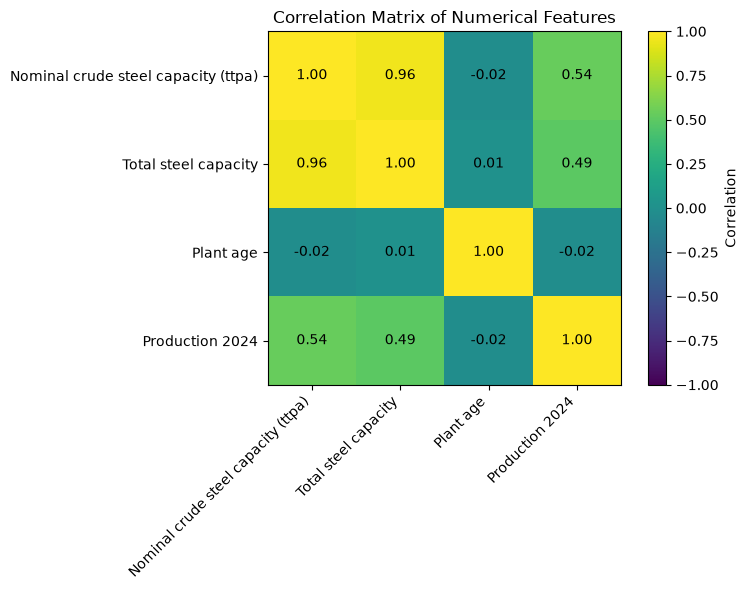

In [6]:
import matplotlib.pyplot as plt

# Aggregate 2024 production to one value per plant
production_2024 = (
    production_clean
    .groupby("GEM plant ID", as_index=False)[2024]
    .sum(min_count=1)
    .rename(columns={2024: "Production 2024"})
)

# Add production target to feature dataset
correlation_data = features_encoded.merge(
    production_2024,
    on="GEM plant ID",
    how="inner"
)

# Select main numerical variables for an interpretable matrix
corr_cols = [
    "Nominal crude steel capacity (ttpa)",
    "Total steel capacity",
    "Plant age",
    "Production 2024"
]

corr_matrix = correlation_data[corr_cols].corr()

print("Correlation matrix:")
display(corr_matrix)

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_matrix, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

# Add correlation values inside cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

> 📝 *Critical thinking:*
> Which variables show the strongest correlation with production?
> Do any features appear redundant or highly correlated with each other?


We can see that steel capacity has the strongest relationship with production. Crude steel capacity has a correlation of around 0.54 with production, while total steel capacity is around 0.49. Plant age has almost no correlation with production at -0.02. Crude steel capacity and total steel capacity are also very highly correlated with each other at 0.96, so they may be giving us mostly the same information and could be redundant in the model.

## 🧮 2. Building Baseline & Linear Models

### 🧭 Objective
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (mean or median production) with `sklearn.dummy.DummyRegressor`. Report RMSE and MAE on the held-out test set.
- Build a second baseline as a pipeline, using **one** of the following. Fit preprocessing on the training split only (inside the pipeline, not on the full table):
  - **scikit-learn:** a `Pipeline` with preprocessing (`ColumnTransformer`: impute, encode categoricals, scale numerics) and a default regressor.
  - **skrub:** [`tabular_pipeline("regressor")`](https://skrub-data.org/stable/reference/generated/skrub.tabular_pipeline.html), which wires a `TableVectorizer` to an estimator-appropriate preprocessor.
- Compare the pipeline’s RMSE and MAE with the dummy baseline.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Aggregate 2024 production to one row per plant
production_2024 = (
    production_clean
    .groupby("GEM plant ID", as_index=False)[2024]
    .sum(min_count=1)
    .rename(columns={2024: "Production 2024"})
)

# Create modelling table
model_data = capacity_clean.merge(
    production_2024,
    on="GEM plant ID",
    how="inner"
)

# Keep rows where target known
model_data = model_data.dropna(subset=["Production 2024"])

# Basleine model features
feature_cols = [
    "Nominal crude steel capacity (ttpa)",
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Status",
    "Main production equipment"
]

X = model_data[feature_cols]
y = model_data["Production 2024"]

# Held-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Dummy baseline: always predicts training-set median production.
dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_pred))
dummy_mae = mean_absolute_error(y_test, dummy_pred)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

print("\nDummy Baseline Results")
print(f"RMSE: {dummy_rmse:.2f}")
print(f"MAE:  {dummy_mae:.2f}")
print(f"Median training production: {dummy.constant_[0][0]:.2f} ttpa")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

# Separate numerical and categorical features
numeric_features = [
    "Nominal crude steel capacity (ttpa)",
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)"
]

categorical_features = [
    "Status",
    "Main production equipment"
]

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Full pipeline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train only on training data
baseline_model.fit(X_train, y_train)

# Predict on held-out test data
baseline_pred = baseline_model.predict(X_test)

# Evaluate
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)
baseline_mae = mean_absolute_error(
    y_test, baseline_pred
)

print("\nLinear Regression Pipeline Results")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"MAE:  {baseline_mae:.2f}")

print("\nComparison")
print(f"Dummy RMSE:  {dummy_rmse:.2f}")
print(f"Linear RMSE: {baseline_rmse:.2f}")
print(f"Dummy MAE:   {dummy_mae:.2f}")
print(f"Linear MAE:  {baseline_mae:.2f}")

Training observations: 376
Test observations: 94

Dummy Baseline Results
RMSE: 9638.28
MAE:  5564.64
Median training production: 2978.00 ttpa

Linear Regression Pipeline Results
RMSE: 7690.26
MAE:  5049.96

Comparison
Dummy RMSE:  9638.28
Linear RMSE: 7690.26
Dummy MAE:   5564.64
Linear MAE:  5049.96


> 📝 *Critical thinking:*
> Why is it useful to have a baseline model before trying more complex ones?
> Did your pipeline beat the dummy baseline? If the gap is small, what does that say about the features?

We chose the median rather than the mean for the dummy baseline because the production data is quite skewed and contains some very high values, so the median is less affected by these extreme values. The linear regression model performs better than the dummy baseline, with the RMSE decreasing from 9638 to 7690 and the MAE decreasing from 5565 to 5050. This shows that the features we used do give the model useful information about production. However, the errors are still quite high, meaning that the baseline model is still not very accurate and there is room to improve it with better models or features.

### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.
- Display coefficients and interpret their meaning.
- Evaluate the model on training and test data.


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train multiple linear regression using same preprocessing from previous task
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

# Predictions
train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)

# Evaluate training and test performance
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Linear Regression Performance")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test RMSE:     {test_rmse:.2f}")
print(f"Training MAE:  {train_mae:.2f}")
print(f"Test MAE:      {test_mae:.2f}")
print(f"Training R²:   {train_r2:.3f}")
print(f"Test R²:       {test_r2:.3f}")

# Get feature names after preprocessing
feature_names = linear_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get regression coefficients
coefficients = linear_model.named_steps[
    "model"
].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort from largest positive to largest negative
coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
).reset_index(drop=True)

print("\nModel Coefficients:")
display(coef_df)

Linear Regression Performance
Training RMSE: 8490.61
Test RMSE:     7690.26
Training MAE:  4706.28
Test MAE:      5049.96
Training R²:   0.433
Test R²:       0.269

Model Coefficients:


,Feature,Coefficient
0,cat__Main production equipment_Steel other/uns...,17629.059336
1,num__Nominal crude steel capacity (ttpa),12746.401410
2,cat__Main production equipment_BF,10087.608651
3,cat__Main production equipment_BOF,9882.726783
4,cat__Main production equipment_BF; DRI; EAF,6105.297765
5,cat__Main production equipment_DRI,5824.187449
6,cat__Main production equipment_BF; Steel other...,5216.488784
7,cat__Main production equipment_BF; EAF,4968.727416
8,cat__Main production equipment_BF; DRI; IF,4829.291345
9,cat__Status_construction,4237.365100


> 📝 *Critical thinking:*
> Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?


We can see that crude steel capacity has a positive coefficient, meaning that plants with higher capacity are generally predicted to have higher production. On the other hand, EAF steel capacity has a negative coefficient in our model, meaning that when the other variables are kept constant, higher EAF capacity is associated with lower predicted production. However, we should be careful when interpreting these coefficients since some of the capacity variables are highly correlated with each other, which can affect the size and direction of the coefficients.


## 🔁 3. Model Evaluation and Selection

### 🧭 Objective
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).
- Record the average RMSE, MAE, and R² across folds.


In [9]:
from sklearn.model_selection import KFold, cross_validate

# 5-fold cross-validation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate full pipeline
cv_results = cross_validate(
    linear_model,
    X,
    y,
    cv=kfold,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

# Convert negative sklearn error scores back to positive values
rmse_scores = -cv_results["test_rmse"]
mae_scores = -cv_results["test_mae"]
r2_scores = cv_results["test_r2"]

# Display each fold
cv_table = pd.DataFrame({
    "Fold": range(1, 6),
    "RMSE": rmse_scores,
    "MAE": mae_scores,
    "R²": r2_scores
})

print("5-Fold Cross-Validation Results:")
display(cv_table.round(3))

# Average performance and variability
print("\nAverage Cross-Validation Performance")
print(f"Average RMSE: {rmse_scores.mean():.2f}")
print(f"Average MAE:  {mae_scores.mean():.2f}")
print(f"Average R²:   {r2_scores.mean():.3f}")

print("\nVariation Across Folds")
print(f"RMSE std: {rmse_scores.std():.2f}")
print(f"MAE std:  {mae_scores.std():.2f}")
print(f"R² std:   {r2_scores.std():.3f}")

5-Fold Cross-Validation Results:


,Fold,RMSE,MAE,R²
0,1,7690.255,5049.963,0.269
1,2,10364.326,5115.755,0.066
2,3,9164.279,5189.517,0.023
3,4,9715.685,5712.483,0.350
4,5,11470.590,6024.212,0.177



Average Cross-Validation Performance
Average RMSE: 9681.03
Average MAE:  5418.39
Average R²:   0.177

Variation Across Folds
RMSE std: 1257.05
MAE std:  382.94
R² std:   0.122


> 📝 *Critical thinking:*
> Summarize your results. How stable is performance across folds? What might this indicate about model variance?

Performance varies across the five folds: average RMSE is about 9681, average MAE is 5418, and average R² is 0.177. R² ranges from about 0.02 to 0.35. This suggests the model’s measured performance depends on which plants fall into each fold, so a single test split would give an incomplete picture.

### **Task 3.2 – Model Comparison**
Train and compare at least **three models**, on the same folds and metrics as Task 3.1:
- Linear Regression
- Ridge Regression (regularized linear)
- Random Forest Regressor

Record cross-validation performance for each model.

**Bonus — tabular foundation model:** add [TabFM](https://github.com/google-research/tabfm) v1.0 (Google Research). Install the PyTorch extra from that repo, then:

```python
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

reg = TabFMRegressor(model=tabfm_v1_0_0.load(model_type="regression"))
```

`fit` stores the training rows as context; `predict` is one forward pass, with no hyperparameter search. The default context is 100 rows (`max_num_rows`). A single held-out split is enough. Pretrained weights are non-commercial and not for production. In the results table, say whether it beats your best classical model, and which model you would actually deploy. Python 3.11 or newer is required.


In [10]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# Models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

# Use same 5 folds and metrics as Task 3.1
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=kfold,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        }
    )

    rmse = -scores["test_rmse"]
    mae = -scores["test_mae"]
    r2 = scores["test_r2"]

    results.append({
        "Model": name,
        "Average RMSE": rmse.mean(),
        "RMSE Std": rmse.std(),
        "Average MAE": mae.mean(),
        "MAE Std": mae.std(),
        "Average R²": r2.mean(),
        "R² Std": r2.std()
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Sort by lowest RMSE
results_df = results_df.sort_values(
    "Average RMSE"
).reset_index(drop=True)

print("Model Comparison - 5-Fold Cross-Validation")
display(results_df.round(3))

Model Comparison - 5-Fold Cross-Validation


,Model,Average RMSE,RMSE Std,Average MAE,MAE Std,Average R²,R² Std
0,Random Forest,8667.691,1347.438,4749.618,701.357,0.346,0.077
1,Ridge Regression,8992.534,1220.302,5042.776,423.692,0.292,0.098
2,Linear Regression,9681.027,1257.047,5418.386,382.941,0.177,0.122


> 📝 *Critical thinking:*
> Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?


We can see that the Random Forest performs the best overall, with the lowest average RMSE and MAE and the highest average R² of 0.346. Ridge Regression also improves on Linear Regression, which suggests that regularization helps with some of the highly correlated features we identified earlier. Random Forest likely performs better because the relationships between plant characteristics and production are not completely linear. It can capture more complex relationships between variables such as capacity, equipment type and plant status that the linear models may miss. However, the errors are still quite high, so there is still a lot of variation in production that our current features do not explain.


### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).
- Report the best parameters and corresponding validation score.


In [11]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameters to test
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 1.0]
}

# Randomized search using same 5-fold CV
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=kfold,
    random_state=42,
    n_jobs=-1
)

# Fit the search
random_search.fit(X, y)

# Best validation RMSE
best_rmse = -random_search.best_score_

print("Best Hyperparameters:")
for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validation RMSE: {best_rmse:.2f}")

# Compare against default Random Forest from previous task
default_rf_rmse = results_df.loc[
    results_df["Model"] == "Random Forest",
    "Average RMSE"
].iloc[0]

print("\nComparison with Default Random Forest")
print(f"Default RF Average RMSE: {default_rf_rmse:.2f}")
print(f"Tuned RF Average RMSE:   {best_rmse:.2f}")
print(f"RMSE Improvement:        {default_rf_rmse - best_rmse:.2f}")

Best Hyperparameters:
model__n_estimators: 500
model__min_samples_split: 2
model__min_samples_leaf: 2
model__max_features: 1.0
model__max_depth: 5

Best Cross-Validation RMSE: 8417.40

Comparison with Default Random Forest
Default RF Average RMSE: 8667.69
Tuned RF Average RMSE:   8417.40
RMSE Improvement:        250.29


> 📝 *Critical thinking:*
> Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?


Hyperparameter tuning helps us find settings that are better suited to our dataset instead of only using the default settings. In our case, tuning improved the Random Forest RMSE from 8668 to 8417, which is an improvement of around 250. The improvement is not huge, but it shows that changing parameters such as the number of trees and maximum depth can improve the model's performance. The best maximum depth was 5, which may also help prevent the model from becoming too complex and overfitting the training data.


## ⚙️ 4. Model Lifecycle: Tracking, Saving, and Loading

### 🧭 Objective
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (a plot, the feature list, or your Pandera schema).
- Run and record at least two experiments (for example the Task 2.1 baseline and your best model).


In [12]:
import mlflow
import json
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score

# Store MLflow experiment data in a local SQLite database
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Create/select MLflow experiment
mlflow.set_experiment("GIST Steel Production")

# Save feature list as artifact
with open("feature_list.json", "w") as f:
    json.dump(feature_cols, f, indent=4)


# Experiment 1: Linear Regression
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

with mlflow.start_run(run_name="Linear Regression Baseline"):

    mlflow.log_param("model_type", "Linear Regression")

    mlflow.log_metric("test_rmse", linear_rmse)
    mlflow.log_metric("test_r2", linear_r2)

    mlflow.log_artifact("feature_list.json")

print("Linear Regression experiment logged.")


# Experiment 2: Tuned Random Forest
best_rf = random_search.best_estimator_

best_rf.fit(X_train, y_train)
rf_pred = best_rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

with mlflow.start_run(run_name="Tuned Random Forest"):

    mlflow.log_param("model_type", "Random Forest")

    # Log best hyperparameters
    for param, value in random_search.best_params_.items():
        mlflow.log_param(param, value)

    mlflow.log_metric("test_rmse", rf_rmse)
    mlflow.log_metric("test_r2", rf_r2)

    mlflow.log_artifact("feature_list.json")

print("Tuned Random Forest experiment logged.")


# Display comparison
tracking_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Tuned Random Forest"
    ],
    "Test RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "Test R²": [
        linear_r2,
        rf_r2
    ]
})

print("\nMLflow Experiment Results:")
display(tracking_results.round(3))

C:\Users\fabri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/09/27 18:39:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/27 18:39:57 INFO mlflow.store.db.utils: Updating database tables
2026/09/27 18:39:59 INFO mlflow.tracking.fluent: Experiment with name 'GIST Steel Production' does not exist. Creating a new experiment.


Linear Regression experiment logged.
Tuned Random Forest experiment logged.

MLflow Experiment Results:


,Model,Test RMSE,Test R²
0,Linear Regression,7690.257,0.269
1,Tuned Random Forest,6627.554,0.457


> 📝 *Critical thinking:*
> Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?


MLflow helps us keep track of our different experiments by storing the model parameters, metrics and artifacts in one place. This makes it easier for us to compare models and reproduce previous results without having to manually keep track of everything. For example, we can directly compare our Linear Regression and tuned Random Forest runs and see which one performed better. This is especially useful as we test more models and parameters, since manual tracking could quickly become confusing and make it easier to lose or mix up results.


### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one classical model (Ridge or Random Forest). Skip TabFM here.
- Use a fixed budget (about 30 trials) and the same cross-validation metric as Task 3.
- Record the number of trials, the best parameters, and the score next to the untuned score from Task 3.2.
- Send the trials to the same store as Task 4.1 with `optuna.integration.MLflowCallback`.


In [13]:
import optuna
import mlflow

from optuna.integration import MLflowCallback
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Use same MLflow experiment as previous task
mlflow.set_experiment("GIST Steel Production")

# Objective function Optuna will minimize
def objective(trial):

    # Hyperparameters suggested by Optuna
    n_estimators = trial.suggest_int(
        "n_estimators", 100, 500, step=50
    )

    max_depth = trial.suggest_int(
        "max_depth", 3, 20
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split", 2, 10
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf", 1, 5
    )

    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2", 1.0]
    )

    # Build model
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", rf)
    ])

    # Same 5-fold CV and RMSE as Task 3
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=kfold,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()


# Create study
study = optuna.create_study(
    direction="minimize",
    study_name="Random Forest Optuna"
)

# Log trials to MLflow
mlflow_callback = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name="cv_rmse"
)

# Run fixed budget of 30 trials
study.optimize(
    objective,
    n_trials=30,
    callbacks=[mlflow_callback]
)

# Results
optuna_rmse = study.best_value
untuned_rmse = 8667.691

print("\nOptuna Optimization Results")
print(f"Number of trials: {len(study.trials)}")

print("\nBest Parameters:")
for parameter, value in study.best_params.items():
    print(f"{parameter}: {value}")

print(f"\nUntuned Random Forest RMSE: {untuned_rmse:.2f}")
print(f"Optuna Best CV RMSE:        {optuna_rmse:.2f}")
print(f"RMSE Improvement:           {untuned_rmse - optuna_rmse:.2f}")

[I 2026-09-27 18:40:11,089] A new study created in memory with name: Random Forest Optuna
C:\Users\fabri\AppData\Local\Temp\ipykernel_18580\2322291538.py:73: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
[I 2026-09-27 18:40:12,259] Trial 0 finished with value: 8724.763047065597 and parameters: {'n_estimators': 500, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 1.0}. Best is trial 0 with value: 8724.763047065597.
2026/09/27 18:40:12 INFO mlflow.tracking.fluent: Experiment with name 'Random Forest Optuna' does not exist. Creating a new experiment.
[I 2026-09-27 18:40:13,359] Trial 1 finished with value: 8661.98004851147 and parameters: {'n_estimators': 450, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 8661.98004851147.
[I 2026-09-27 18:4


Optuna Optimization Results
Number of trials: 30

Best Parameters:
n_estimators: 100
max_depth: 6
min_samples_split: 2
min_samples_leaf: 4
max_features: 1.0

Untuned Random Forest RMSE: 8667.69
Optuna Best CV RMSE:        8441.36
RMSE Improvement:           226.33


> 📝 *Critical thinking:*
> Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?


Optuna tests different hyperparameter combinations and uses earlier trials to guide later ones. After 30 trials, its best cross-validation RMSE was 8441.36, compared with 8667.69 for the untuned Random Forest, which is an improvement of 226.33. Grid Search checks a fixed set of combinations, while Random Search samples them randomly.


### **Task 4.3 – Model Storage**
- Save the best **pipeline** (preprocessing and model together), with `joblib` or `mlflow.sklearn.log_model`. Saving the estimator alone drops the encoder and imputer.
- Load the saved pipeline and re-evaluate it on the test set. The score should match the in-memory pipeline.


In [14]:
import joblib
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Fit best pipeline using best parameters from Task 3.3
best_pipeline = rf_pipeline.set_params(**random_search.best_params_)
best_pipeline.fit(X_train, y_train)

# Evaluate before saving
pred_before = best_pipeline.predict(X_test)

rmse_before = mean_squared_error(y_test, pred_before) ** 0.5
mae_before = mean_absolute_error(y_test, pred_before)
r2_before = r2_score(y_test, pred_before)

# Save entire pipeline
model_path = "best_steel_production_pipeline.joblib"
joblib.dump(best_pipeline, model_path)

# Load pipeline back
loaded_pipeline = joblib.load(model_path)

# Re-evaluate after loading
pred_after = loaded_pipeline.predict(X_test)

rmse_after = mean_squared_error(y_test, pred_after) ** 0.5
mae_after = mean_absolute_error(y_test, pred_after)
r2_after = r2_score(y_test, pred_after)

print("Model Storage Check")
print(f"Saved to: {model_path}")

print("\nBefore saving:")
print(f"RMSE: {rmse_before:.2f}")
print(f"MAE:  {mae_before:.2f}")
print(f"R²:   {r2_before:.3f}")

print("\nAfter loading:")
print(f"RMSE: {rmse_after:.2f}")
print(f"MAE:  {mae_after:.2f}")
print(f"R²:   {r2_after:.3f}")

print("\nPredictions match:", 
      np.allclose(pred_before, pred_after))

Model Storage Check
Saved to: best_steel_production_pipeline.joblib

Before saving:
RMSE: 6627.55
MAE:  3779.75
R²:   0.457

After loading:
RMSE: 6627.55
MAE:  3779.75
R²:   0.457

Predictions match: True


> 📝 *Critical thinking:*
> Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?


We need to store both the model parameters and metadata so we know exactly how a model was created and can reproduce the same results later. This includes things like the preprocessing steps, hyperparameters, features used and performance metrics. In our case, saving the entire pipeline allowed us to load it again and get exactly the same predictions and performance. In production, we could use MLflow to keep different model versions and their information organized, so we can compare versions and go back to an older model if a new one performs worse.


## 🚀 5. Deployment & Monitoring (Conceptual)

### 🧭 Objective
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**

> 📝 *Critical thinking:*
> Describe how you would deploy the **saved pipeline** from Task 4.3 (REST API or batch job). Incoming rows should pass your Pandera schema before `predict`, so serving applies the same columns and checks as training.
> Which metrics would you monitor: error once actual production arrives, and the share of rows rejected by the schema?
> If you tried TabFM, would you deploy it or the classical pipeline? The pretrained weights are non-commercial and not for production use.


We would deploy the saved pipeline through a REST API. Before prediction, we would validate incoming data rows against a Pandera schema matching the five columns/features used by the saved pipeline: the three capacity columns, status, and main production equipment. We would monitor the share of rejected rows and, once actual production is available, prediction error using RMSE and MAE. We would deploy the tuned Random Forest pipeline.


### **Task 5.2 – Detecting Model Drift**

> 📝 *Critical thinking:*
> What signs might indicate your model needs retraining?
> Give one example of **data drift** and one of **concept drift** relevant to steel plant production.
> Name one column from your Pandera schema you would watch first, and what shift in that column would count as data drift.


One sign that our model needs retraining would be if its RMSE and MAE start increasing when we compare predictions with new actual production values. An example of data drift could be if the capacities of steel plants in new data become much larger than the capacities in our training data. We would therefore watch the Nominal crude steel capacity (ttpa) column first, since capacity had one of the strongest relationships with production. A major shift in its average or distribution compared to the training data would count as data drift. Concept drift would be different: for example, if plants start producing much less relative to their capacity because of changes in demand, energy costs or production methods. In this case, the input data may still look similar, but the relationship between capacity and actual production has changed.


## 💬 6. Feedback

> 📝 *Critical thinking:*
> 1. Which step of the modelling lifecycle did you find most challenging and why?


We found the data preparation and validation steps the most challenging because the raw dataset had missing values, inconsistent data types and several different tables that had to be combined correctly. We had to make sure the data was clean while also not removing useful information before training the models.


> 2. What would you do differently if you had access to additional plant-level data?


With more plant-level data, we would include variables that could explain why plants with similar capacities have different production levels. For example, we could include energy costs, utilization rates, downtime, maintenance, demand and more detailed information about production technology. This could help the model explain more of the variation in production and improve its predictions.


> 3. How would you communicate model insights to a business audience?


We would focus more on the main results and business impact instead of explaining all the technical details of the model. We could use simple graphs or a dashboard to show predicted versus actual production, the most important factors affecting production and how accurate the model is. We would also explain the limitations of the model so the predictions are used as support for decisions rather than treated as exact values.


